### Imports & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42

data = load_breast_cancer()
X_full, y = data.data, data.target
feature_names = data.feature_names

print("Feature matrix shape:", X_full.shape)


Feature matrix shape: (569, 30)


### Which Features Are Actually Skewed?

Before injecting any missing values, let's establish the ground truth: which of these 30 features are symmetric (skewness near 0) and which are heavily skewed (skewness far from 0)? This dataset is a good test case because it has both things like `mean symmetry` are close to normal, while things like `mean area` or `area error` are heavily right-skewed (a few very large tumors pull the tail out).


In [2]:
skewness = pd.Series(skew(X_full, axis=0), index=feature_names).sort_values()

print("Most symmetric features (skewness near 0):")
print(skewness.head(5))
print()
print("Most skewed features (skewness far from 0):")
print(skewness.tail(5))


Most symmetric features (skewness near 0):
worst smoothness        0.414330
mean smoothness         0.455120
worst concave points    0.491316
worst texture           0.497007
mean texture            0.648734
dtype: float64

Most skewed features (skewness far from 0):
radius error               3.080464
perimeter error            3.434530
fractal dimension error    3.913617
concavity error            5.096981
area error                 5.432816
dtype: float64


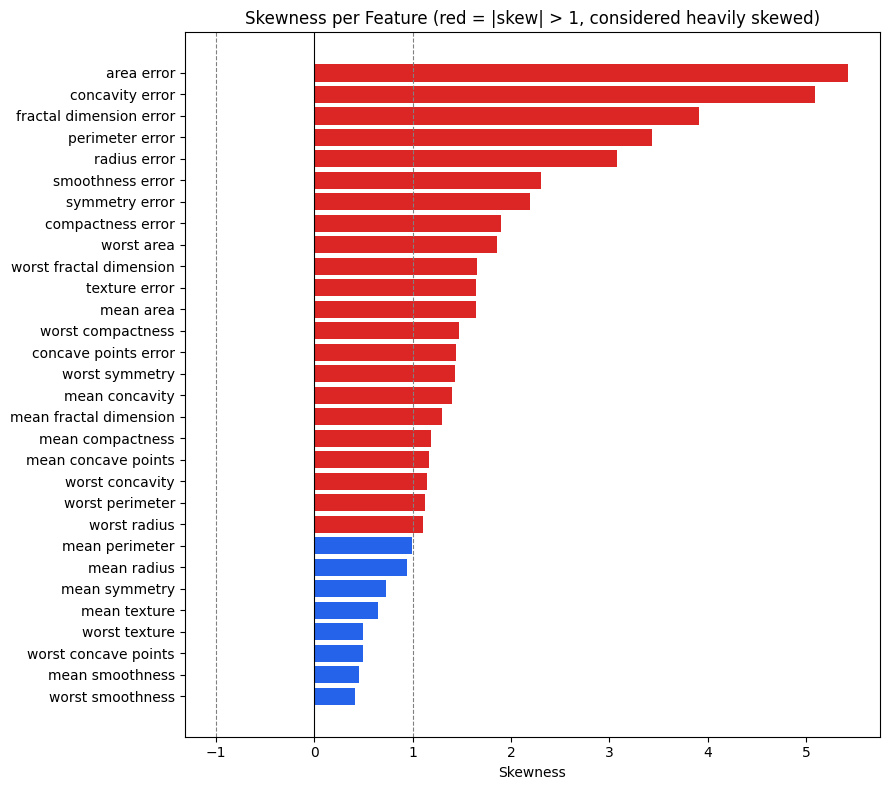

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#dc2626" if abs(v) > 1 else "#2563eb" for v in skewness.values]
ax.barh(skewness.index, skewness.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(1, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Skewness")
ax.set_title("Skewness per Feature (red = |skew| > 1, considered heavily skewed)")
plt.tight_layout()
plt.show()


#### Visual check: a skewed feature vs a symmetric feature

Picking the most skewed and most symmetric features from above, and plotting their distributions with mean and median both marked , this is the visual version of the whole hypothesis.


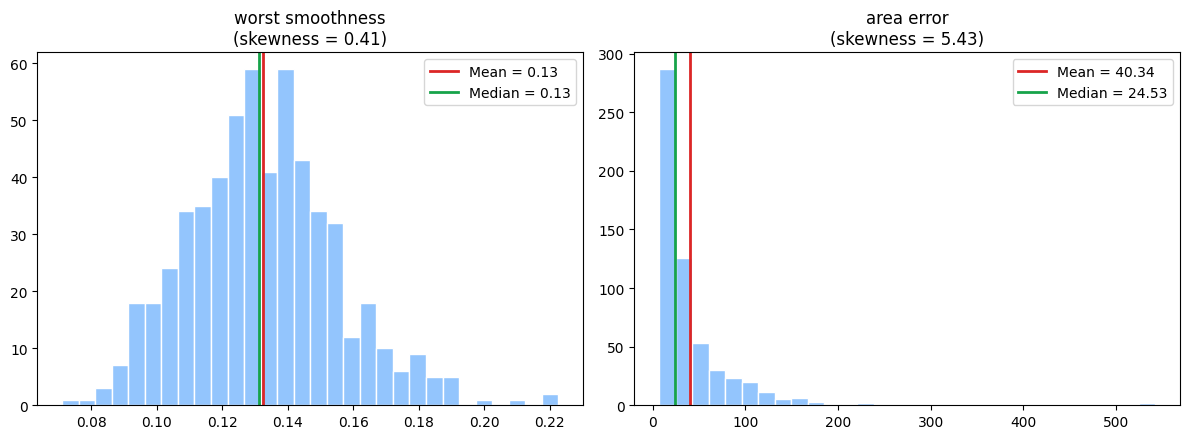

In [4]:
most_skewed_feature = skewness.index[-1]
most_symmetric_feature = skewness.abs().sort_values().index[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, feat in zip(axes, [most_symmetric_feature, most_skewed_feature]):
    col = X_full[:, list(feature_names).index(feat)]
    ax.hist(col, bins=30, color="#93c5fd", edgecolor="white")
    ax.axvline(col.mean(), color="#dc2626", linewidth=2, label=f"Mean = {col.mean():.2f}")
    ax.axvline(np.median(col), color="#16a34a", linewidth=2, label=f"Median = {np.median(col):.2f}")
    ax.set_title(f"{feat}\n(skewness = {skew(col):.2f})")
    ax.legend()

plt.tight_layout()
plt.show()


**Reading this plot:** on the symmetric feature, mean and median should sit
almost on top of each other. On the skewed feature, they should visibly
separate, the mean gets dragged toward the long tail, while the median stays
anchored near where most of the data actually is.


###  Simulate missing data

The real dataset has no missing values, so we inject some ourselves, 15% of all
cells, missing completely at random (MCAR), with a fixed seed. Critically, we
keep the original `X_full` around as ground truth, so we can later measure how
close each imputation method gets to the real value it was hiding.


In [5]:
MISSING_FRACTION = 0.15

rng = np.random.RandomState(RANDOM_STATE)
missing_mask_full = rng.rand(*X_full.shape) < MISSING_FRACTION

X_missing = X_full.copy()
X_missing[missing_mask_full] = np.nan

print(f"Total values: {X_full.size}")
print(f"Missing values injected: {missing_mask_full.sum()} ({missing_mask_full.mean():.1%})")


Total values: 17070
Missing values injected: 2588 (15.2%)


In [6]:
X_full_train, X_full_test, X_missing_train, X_missing_test, y_train, y_test = train_test_split(
    X_full, X_missing, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

mask_train = np.isnan(X_missing_train)
mask_test = np.isnan(X_missing_test)

print("Train shape:", X_missing_train.shape, "| Test shape:", X_missing_test.shape)


Train shape: (455, 30) | Test shape: (114, 30)


### Impute : Mean vs. Median

Both imputers are fit on the training data only (using its own column means /
medians) and then applied to the test data too, avoiding any leakage from test
into train.


In [7]:
mean_imputer = SimpleImputer(strategy="mean")
X_train_mean = mean_imputer.fit_transform(X_missing_train)
X_test_mean = mean_imputer.transform(X_missing_test)

median_imputer = SimpleImputer(strategy="median")
X_train_median = median_imputer.fit_transform(X_missing_train)
X_test_median = median_imputer.transform(X_missing_test)

print("Imputation done. No NaNs remaining:",
      not np.isnan(X_train_mean).any(), not np.isnan(X_train_median).any())


Imputation done. No NaNs remaining: True True


###  Imputation quality: how close did each method get to the real value?

Because we know the real values we hid (`X_full_train` / `X_full_test`), we can
directly measure the error of each imputation method, per feature, using Mean
Absolute Error (MAE) computed only at the positions that were actually missing.



In [8]:
def imputation_mae_per_feature(X_imputed_train, X_imputed_test):
    maes = []
    for j in range(X_full.shape[1]):
        true_vals = np.concatenate([
            X_full_train[mask_train[:, j], j],
            X_full_test[mask_test[:, j], j],
        ])
        pred_vals = np.concatenate([
            X_imputed_train[mask_train[:, j], j],
            X_imputed_test[mask_test[:, j], j],
        ])
        maes.append(np.mean(np.abs(true_vals - pred_vals)))
    return np.array(maes)

mean_mae = imputation_mae_per_feature(X_train_mean, X_test_mean)
median_mae = imputation_mae_per_feature(X_train_median, X_test_median)

imputation_quality = pd.DataFrame({
    "Feature": feature_names,
    "Skewness": skewness.reindex(feature_names).values,
    "Mean Imputation MAE": mean_mae,
    "Median Imputation MAE": median_mae,
})
imputation_quality["Better Method"] = np.where(
    imputation_quality["Mean Imputation MAE"] < imputation_quality["Median Imputation MAE"],
    "Mean", "Median"
)
imputation_quality["Abs Skewness"] = imputation_quality["Skewness"].abs()
imputation_quality.sort_values("Abs Skewness", ascending=False).round(4)


,Feature,Skewness,Mean Imputation MAE,Median Imputation MAE,Better Method,Abs Skewness
13,area error,5.4328,30.3780,26.2736,Median,5.4328
16,concavity error,5.0970,0.0159,0.0168,Mean,5.0970
19,fractal dimension error,3.9136,0.0016,0.0014,Median,3.9136
12,perimeter error,3.4345,1.2082,1.2165,Mean,3.4345
10,radius error,3.0805,0.2113,0.1998,Median,3.0805
14,smoothness error,2.3083,0.0023,0.0023,Median,2.3083
18,symmetry error,2.1893,0.0064,0.0059,Median,2.1893
15,compactness error,1.8972,0.0149,0.0145,Median,1.8972
23,worst area,1.8545,493.9185,450.3912,Median,1.8545
29,worst fractal dimension,1.6582,0.0160,0.0159,Median,1.6582


In [9]:
print(imputation_quality["Better Method"].value_counts())


Better Method
Median    21
Mean       9
Name: count, dtype: int64


#### Does skewness actually predict which method wins?

Plotting absolute skewness against how much better median did than mean
(`Mean MAE - Median MAE`), if the hypothesis is right, this should trend
upward: the more skewed a feature is, the more median should out perform mean.


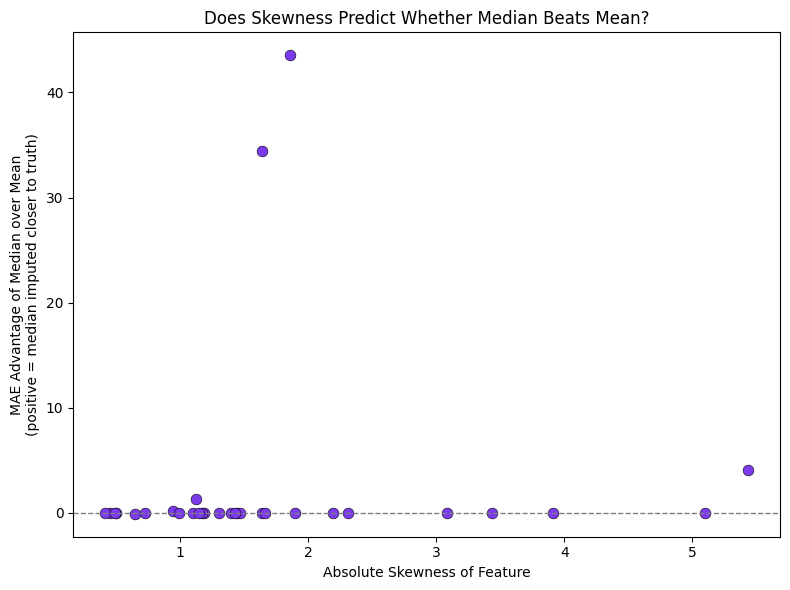

Correlation between |skewness| and median's MAE advantage: 0.0438


In [10]:
imputation_quality["MAE Advantage of Median"] = (
    imputation_quality["Mean Imputation MAE"] - imputation_quality["Median Imputation MAE"]
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(imputation_quality["Abs Skewness"], imputation_quality["MAE Advantage of Median"],
           color="#7c3aed", s=60, edgecolors="k", linewidths=0.4)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Absolute Skewness of Feature")
ax.set_ylabel("MAE Advantage of Median over Mean\n(positive = median imputed closer to truth)")
ax.set_title("Does Skewness Predict Whether Median Beats Mean?")
plt.tight_layout()
plt.show()

correlation = imputation_quality["Abs Skewness"].corr(imputation_quality["MAE Advantage of Median"])
print(f"Correlation between |skewness| and median's MAE advantage: {correlation:.4f}")


### Downstream model performance: mean imputed vs median imputed

Imputation accuracy is one thing, but does it actually change what a model
predicts? Same three models as before, trained once on the mean imputed data and
once on the median imputed data (both scaled with `StandardScaler`, fit on
training data only).


In [11]:
scaler_mean = StandardScaler()
X_train_mean_scaled = scaler_mean.fit_transform(X_train_mean)
X_test_mean_scaled = scaler_mean.transform(X_test_mean)

scaler_median = StandardScaler()
X_train_median_scaled = scaler_median.fit_transform(X_train_median)
X_test_median_scaled = scaler_median.transform(X_test_median)

results = []  # dicts: Imputation, Model, Accuracy


#### Model 1: Logistic regression : mean imputation

In [12]:
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
model.fit(X_train_mean_scaled, y_train)
acc = accuracy_score(y_test, model.predict(X_test_mean_scaled))
results.append({"Imputation": "Mean", "Model": "Logistic Regression", "Accuracy": acc})
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9737


#### Model 1: Logistic regression : median imputation

In [13]:
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
model.fit(X_train_median_scaled, y_train)
acc = accuracy_score(y_test, model.predict(X_test_median_scaled))
results.append({"Imputation": "Median", "Model": "Logistic Regression", "Accuracy": acc})
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9737


#### Model 2: KNN :mean imputation

In [14]:
model = KNeighborsClassifier()
model.fit(X_train_mean_scaled, y_train)
acc = accuracy_score(y_test, model.predict(X_test_mean_scaled))
results.append({"Imputation": "Mean", "Model": "KNN", "Accuracy": acc})
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9649


#### Model 2: KNN : median imputation

In [15]:
model = KNeighborsClassifier()
model.fit(X_train_median_scaled, y_train)
acc = accuracy_score(y_test, model.predict(X_test_median_scaled))
results.append({"Imputation": "Median", "Model": "KNN", "Accuracy": acc})
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9561


#### Model 3: Random forest : mean imputation

In [16]:
model = RandomForestClassifier(random_state=RANDOM_STATE)
model.fit(X_train_mean_scaled, y_train)
acc = accuracy_score(y_test, model.predict(X_test_mean_scaled))
results.append({"Imputation": "Mean", "Model": "Random Forest", "Accuracy": acc})
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9386


#### Model 3: Random forest : median imputation

In [17]:
model = RandomForestClassifier(random_state=RANDOM_STATE)
model.fit(X_train_median_scaled, y_train)
acc = accuracy_score(y_test, model.predict(X_test_median_scaled))
results.append({"Imputation": "Median", "Model": "Random Forest", "Accuracy": acc})
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9386


###  Final comparison

In [18]:
results_df = pd.DataFrame(results)
pivot = results_df.pivot(index="Model", columns="Imputation", values="Accuracy").round(4)
pivot = pivot[["Mean", "Median"]]
pivot["Winner"] = np.where(pivot["Mean"] > pivot["Median"], "Mean",
                    np.where(pivot["Median"] > pivot["Mean"], "Median", "Tie"))
pivot


Imputation,Mean,Median,Winner
Model,,,
KNN,0.9649,0.9561,Mean
Logistic Regression,0.9737,0.9737,Tie
Random Forest,0.9386,0.9386,Tie


In [19]:
print(f"Overall imputation MAE — Mean strategy:   {mean_mae.mean():.4f}")
print(f"Overall imputation MAE — Median strategy: {median_mae.mean():.4f}")
print()
print("Per-feature winner counts (lower MAE = better):")
print(imputation_quality['Better Method'].value_counts())


Overall imputation MAE — Mean strategy:   28.2192
Overall imputation MAE — Median strategy: 25.4326

Per-feature winner counts (lower MAE = better):
Better Method
Median    21
Mean       9
Name: count, dtype: int64
